This notebook demonstrates how to access and analyze data from the MAST S3 bucket using Python. 
It retrieves data for a specific shot ID, explores the structure of the data, and visualises 
key parameters such as NBI power, plasma radiation, fractional power radiated, and plasma current. 
Additionally, it calculates and plots a 2σ threshold for the fractional radiated power to identify 
significant events in the plasma behavior. 

These parameters are then found over many shots and plotted against each other, a pearson correlation
coefficient is calculated to quantify any relationships. It was found that there was little 
correlation between any of the parameters, which could be due to the relatively short range,
or the variables are not strongly correlated.

In [2]:
import zarr
import xarray as xr
import fsspec
import s3fs
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import pandas as pd

def get_data(shot_id):
    """This function retrieves the date for a given shot ID from
    the MAST S3 bucket and returns a Zarr store object.
    
    Parameters:
    shot_id (int): The ID of the shot to retrieve data for.
    
    Returns:
    store: A Zarr store object containing the data for the 
    specified shot.
    """

    endpoint_url = 'https://s3.echo.stfc.ac.uk'
    url = f's3://mast/level2/shots/{shot_id}.zarr'

    # Get a handle to the remote file
    store = zarr.storage.FsspecStore.from_url(
        url,
        storage_options=dict(
            protocol='simplecache',
            target_protocol="s3",
            cache_storage='.cache', # stores the cached data locally
            target_options=dict(
                anon=True, # anonymous connection to S3
                endpoint_url=endpoint_url, 
                asynchronous=True) # doesn't stop notebook
        )
    )
    return store

store = get_data(30422)
# data is structured into groups connected to the root
root = zarr.open(store, mode="r")

# print the tree structure of the data
print(root.tree())


/
├── charge_exchange
│   ├── major_radius (160,) float64
│   ├── t_i (160, 105) float64
│   ├── time (105,) float64
│   └── v_i (160, 105) float64
├── equilibrium
│   ├── beta_pol (105,) float64
│   ├── beta_tor (105,) float64
│   ├── beta_tor_normal (105,) float64
│   ├── bphi_rmag (105,) float64
│   ├── bvac_rmag (105,) float64
│   ├── da_rating (105,) float64
│   ├── elongation (105,) float64
│   ├── elongation_axis (105,) float64
│   ├── ip_rating (105,) float64
│   ├── j_phi (65, 65, 105) float64
│   ├── lcfs_r (157, 105) float64
│   ├── lcfs_z (157, 105) float64
│   ├── li (105,) float64
│   ├── magnetic_axis_r (105,) float64
│   ├── magnetic_axis_z (105,) float64
│   ├── major_radius (65,) float64
│   ├── minor_radius (105,) float64
│   ├── n_boundary_coords (157,) float32
│   ├── n_x_points_r (2,) <U16
│   ├── n_x_points_z (2,) <U16
│   ├── profile_r (65,) float32
│   ├── psi (65, 65, 105) float64
│   ├── q (65, 105) float64
│   ├── q100 (105,) float64
│   ├── q90 (105,) float

In [3]:
def fractional_power(power_injected, power_radiated):
    """Calculate the fractional power radiated given the 
    injected and radiated power.
    
    Parameters:
    power_injected (xarray.DataArray): The power injected into the plasma.
    power_radiated (xarray.DataArray): The power radiated from the plasma.
    
    Returns:
    dict: A dictionary containing the fractional power, and portion of unstable points.
    """
    try:
        # This ensures that data is within a reasonable range and avoids issues with very small values
        mask = power_injected > 1e5 # threshold can be adjusted based on data
       
        # This removes the data points where power inject is below threshold,
        # i.e. at startup and at termnination
        power_injected_masked = power_injected.where(mask, drop=True)
        power_radiated_masked = power_radiated.where(mask, drop=True)

        # Gives fraction of power loss due to radiation and also removes unphysical values
        fractional_power = power_radiated_masked / power_injected_masked
        fractional_power = fractional_power.where( (fractional_power < 2.0) & (fractional_power > -0.5)) # removes unphysical values

        # mean and std of the fractional power radiated
        mean_fraction = fractional_power.mean().values
        std_fraction = fractional_power.std().values

        # Used to estimate where instabilities happen 
        threshold = mean_fraction + 2 * std_fraction
        instability_mask = np.abs(fractional_power) > threshold

        # Points where fractional power exceeds the threshold are considered unstable
        instability_points = fractional_power.where(instability_mask, drop=True)
        fraction_power_no_spike = fractional_power.where(~instability_mask, drop=True) # only consider points where power is below threshold

        # Gets the fraction of points that are unstable
        instability_fraction = instability_points.size / fractional_power.size

        return {'fractional_power': fractional_power, 
                'mean_fraction': mean_fraction,
                'std_fraction': std_fraction,
                'fraction_power_no_spike': fraction_power_no_spike,

                'instability_points': instability_points,
                'instability_fraction': instability_fraction,
                }
                
    except Exception as e: # in case data is missing
        return None


In [4]:
def get_group_average(store, variable, group='summary', apply_nbi_mask=True):
    """Calculate the average of a variable from a given group,
    optionally applying the NBI mask from the summary group.
    
    Parameters:
    store: zarr store object
    variable (str): variable name to average
    group (str): zarr group to load from (default: 'summary')
    apply_nbi_mask (bool): whether to apply NBI mask (default: True)
    
    Returns:
    float: average value of the variable, or None if failed
    """
    try:
        data = xr.open_zarr(store, group=group)
        
        if apply_nbi_mask:
            summary = xr.open_zarr(store, group='summary')
            nbi_mask = summary.power_nbi > 1e5 # applies mask

            # Interpolate the NBI mask to the time points of the variable data, due to different time resolutions
            nbi_interp = nbi_mask.astype(int).interp(time=data.time, method='nearest').astype(bool)
            variable_masked = data[variable].where(nbi_interp)
        else:
            variable_masked = data[variable]
            
        return float(variable_masked.mean().values)
    
    except Exception as e:
        print(f"Failed loading {variable} from {group}: {e}")
        return None

In [5]:
def get_correct_range(store, variable, group='summary', apply_nbi_mask=True):
    """Calculate the correct range of a variable from a given group,
    optionally applying the NBI mask from the summary group.
    
    Parameters:
    store: zarr store object
    variable (str): variable name to average
    group (str): zarr group to load from (default: 'summary')
    apply_nbi_mask (bool): whether to apply NBI mask (default: True)
    
    Returns:
    float: correct range of the variable, or None if failed
    """
    try:
        data = xr.open_zarr(store, group=group)
        
        if apply_nbi_mask:
            summary = xr.open_zarr(store, group='summary')
            nbi_mask = summary.power_nbi > 1e5 # applies mask

            variable_masked = data[variable].where(nbi_mask, drop=True)
        else:
            variable_masked = data[variable]
            
        return variable_masked
    except Exception as e:
        print(f"Failed loading {variable} from {group}: {e}")
        return None

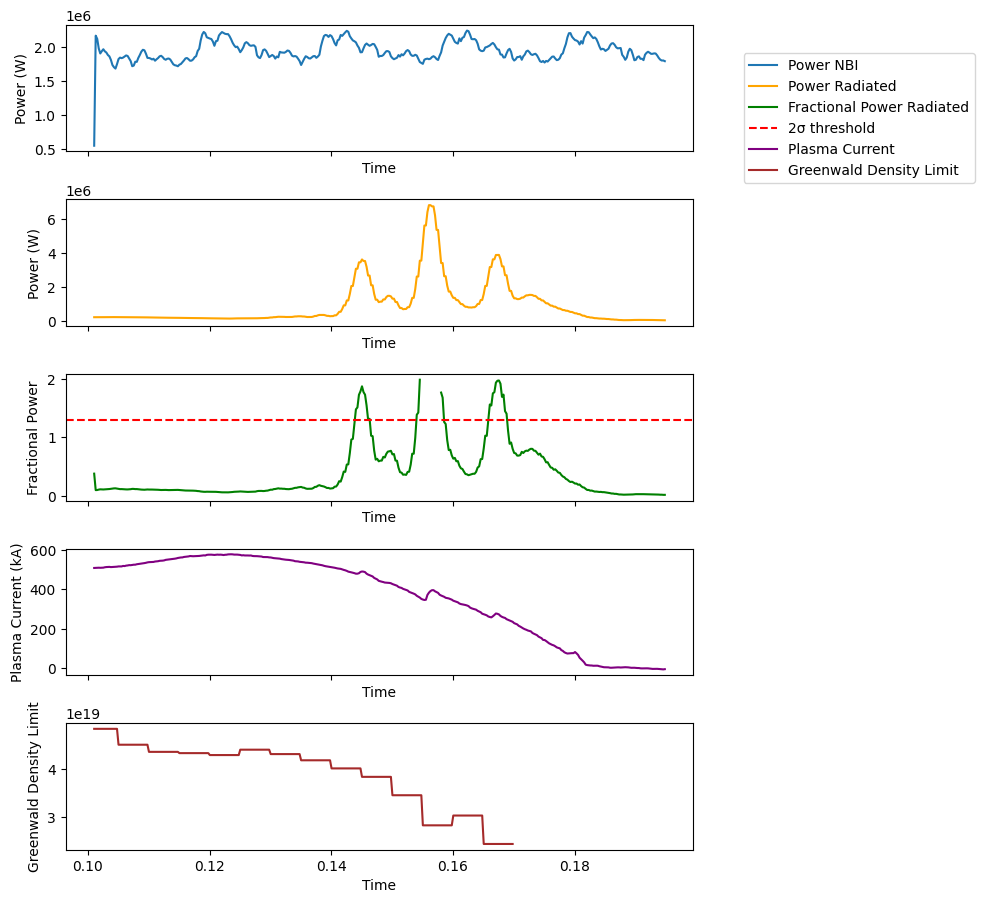

In [7]:

# Example usage for a single shot
store = get_data(30410)

power_data = xr.open_zarr(store, group='summary')

power_injected = power_data.power_nbi
power_radiated = power_data.power_radiated
time = power_data.time
ip = power_data.ip

corrected_power_radiated = get_correct_range(store, 'power_radiated')
corrected_power_injected = get_correct_range(store, 'power_nbi')
corrected_ip = get_correct_range(store, 'ip') / 1000 # converts to kA
corrected_time = corrected_power_injected.time
corrected_greenwald = get_correct_range(store, 'greenwald_density')


fractional_power_result = fractional_power(power_injected, power_radiated)

# Plotting the results
fig, axes = plt.subplots(5, 1, sharex=True)
fig.set_size_inches(7, 9)

l_nbi, = axes[0].plot(corrected_time, corrected_power_injected, label='Power NBI')
axes[0].set_ylabel('Power (W)')
axes[0].set_xlabel('Time')

l_pr, = axes[1].plot(corrected_time, corrected_power_radiated, label='Power Radiated', color='orange')
axes[1].set_ylabel('Power (W)')
axes[1].set_xlabel('Time')

l_fpr, = axes[2].plot(corrected_time, fractional_power_result['fractional_power'], label='Fractional Power Radiated', color='green')
axes[2].set_ylabel('Fractional Power')
axes[2].set_xlabel('Time')

# plots the plasma current 
l_ip, = axes[3].plot(corrected_time, corrected_ip, label='Plasma Current', color='purple')
axes[3].set_ylabel('Plasma Current (kA)')
axes[3].set_xlabel('Time')

l_gw, = axes[4].plot(corrected_time, corrected_greenwald, label='Greenwald Density Limit', color='brown')
axes[4].set_ylabel('Greenwald Density Limit')
axes[4].set_xlabel('Time')

# Calculate the 2σ threshold and plot it
threshold = fractional_power_result['mean_fraction'] + 2 * fractional_power_result['std_fraction']
l_threshold = axes[2].axhline(threshold, color='red', linestyle='--', label='2σ threshold')




# single combined legend outside all plots
fig.legend(handles=[l_nbi, l_pr, l_fpr, l_threshold, l_ip, l_gw], 
           loc='upper right',
           bbox_to_anchor=(1.4, 0.95),
           frameon=True)

fig.tight_layout(pad=0.6)
plt.show()


The figure above shows the the plasma current, fractional power, power radiated, and power NBI. As can be seen in this particular shot, shot_id=30410, some plasma instabilities can be seen, particularly around the 0.14s to 0.17s regions. We also see that plasma current and power radiated decrease to near zero, while power NBI is still in steady state, suggesting that some form of plasma disruption has ocurred causing the shot to fail early.

The data has be sliced in a way that should exclude most of the start up and shut down of the reactor. This has been done by removing any indices where the power NBI is below a certain threshold, in this case 1e5 W was the threshold. 

2σ from the trimmed region's mean is the threshold where we're considering radiation to be unstable. This mean may be skewered, due to the startup and shut-down still being caught in the the trimmed slicing, leading to an underestimated mean, therein overestimating our instabilities. 

It can also be seen that the greenwald density limit independent from any parameters except plasma current, which makes sense, considering $G_d = I_p / (pi * a^2$).

It should also be noted that the fractional power radiated is only divided by the power NBI, and does not include other sources such as ohmic heating.

0.04177109440267335


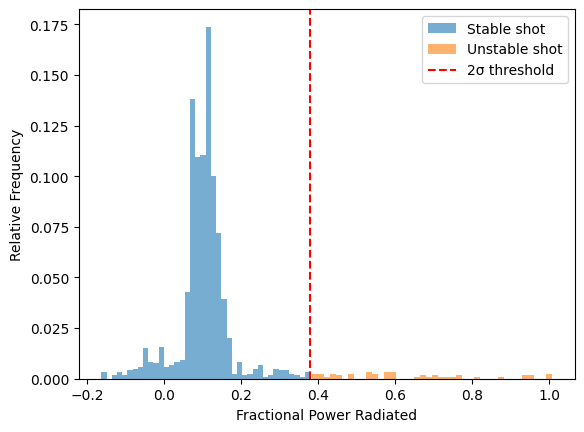

In [ ]:

# Example usage for a single shot
store = get_data(30422)

power_data = xr.open_zarr(store, group='summary')

power_injected = power_data.power_nbi
power_radiated = power_data.power_radiated
time = power_data.time
ip = power_data.ip

result = fractional_power(power_injected, power_radiated)

def get_instability_histogram(results):
    """This function produces a histogram combining the 
    distribution of fractional power radiates for stable points
    and the distribution of points where instabilities are detected.
    
    Parameters:
    results (dict): A dictionary containing fraction_power, mean_fraction,
    std_fraction, fraction_power_no_spike, instability_points, instability_fraction."""

    total = len(results['fractional_power'])

    plt.hist(results['fraction_power_no_spike'].values, 
            bins=40, alpha=0.6, 
            weights=np.ones(len(results['fraction_power_no_spike']))/total,
            label='Stable shot')

    plt.hist(results['instability_points'].values, 
            bins=40, 
            alpha=0.6,
            weights=np.ones(len(results['instability_points']))/total, 
            label='Unstable shot')

    print(results['instability_fraction'])

    plt.axvline(results['mean_fraction'] + 2*results['std_fraction'], color='red', linestyle='--', label='2σ threshold')
    plt.xlabel('Fractional Power Radiated')
    plt.ylabel('Relative Frequency')
    plt.legend()
    plt.show()

get_instability_histogram(result)

This plot shows a histogram of the fractional power radiated across the timescale. This shows that the stable points make a gaussian distribution, which is expected.

We also see the cut-off line for what we consider an instability, as well as our frequency of instabilities measured for this shot. The proportion counted as instable is roughly 4%, which is similar to what you would expect from a gaussian distribution 2 STDs away.

Now to look at multiple shots.

In [ ]:
def many_shots_getting_data(min_shot_id, max_shot_id):
    """This function will loop through a range of shot IDs, retrieve 
    the data for each shot, calculate the fractional power and plasma current
    averages, and store this in a pandas DataFrame for further analysis.
    
    Parameters:
    min_shot_id (int): The minimum shot ID to include in the analysis.
    max_shot_id (int): The maximum shot ID to include in the analysis.

    Returns:
    pd.DataFrame: A DataFrame containing the averages for each shot.
    """

    shot_ids = range(min_shot_id, max_shot_id + 1)

    results = []
    
    for shot_id in shot_ids:
        try:
            store = get_data(shot_id)
            power_data = xr.open_zarr(store, group='summary')
            
            result = fractional_power(power_data.power_nbi, power_data.power_radiated)
            
            # gathers the average of each variable for each shot
            ip_average = get_group_average(store, 'ip')
            n_e_line_average = get_group_average(store, 'line_average_n_e')
            greenwald_density = get_group_average(store, 'greenwald_density')
            a = get_group_average(store, 'minor_radius', group='equilibrium')

            mean_fractional_power = result['mean_fraction']
            instability_fraction = result['instability_fraction']

            # checks if data is missing, if not, adds to results list
            plot_data = [ip_average, n_e_line_average, greenwald_density, a, mean_fractional_power, instability_fraction]
            if None not in plot_data:
                
                results.append({
                    'shot_id': shot_id,
                    'ip_average': ip_average,
                    
                    'n_e_line_average': n_e_line_average,
                    'greenwald_density': greenwald_density,
                    'minor_radius': a,

                    'mean_fractional_power': mean_fractional_power,
                    'instability_fraction': instability_fraction,
                })
            
                # tells us a shot succeeded
                print(f"Shot {shot_id} succeeded")

        # if shot fails, prints why, and continues to next shot
        except Exception as e:
            print(f"Shot {shot_id} failed: {e}")
            continue

    df = pd.DataFrame(results)
    df = df.astype(float, errors='ignore')
    df.to_csv('mast_radiated_power_results.csv', index=False)
    return df

In [ ]:
def add_scatter(axis, fig, x, y, color, ylabel, xlabel, title, vmin, vmax, color_label, ylim=(0, 1), xlim=None):
    """This function adds a scatter plot to a given axis, 
    with points colored by a specified variable.
    
    Parameters:
    axis: matplotlib axis to plot on
    fig: matplotlib figure
    x: x-axis data
    y: y-axis data
    color: color data for each point
    ylabel: label for y-axis
    xlabel: label for x-axis
    title: title for the plot
    vmin: minimum value for color scale
    vmax: maximum value for color scale
    color_label: label for the color bar
    ylim: limits for y-axis (default: (0, 1))
    xlim: limits for x-axis (default: None)
    """

    scatter = axis.scatter(x, y, c=color, cmap='viridis', alpha=0.7,
                           vmin=vmin, vmax=vmax,
                           s=10) # adjust point size as needed

    fig.colorbar(scatter, ax=axis, label=f'$log_{{10}}$({color_label})')
    
    axis.set_ylim(ylim)
    axis.set_xlim(xlim)
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.set_title(title)

    
    # remove NaN values first
    x_arr = np.array(x)
    y_arr = np.array(y)

    # filters out unphysical values
    mask = (np.isfinite(x_arr) & 
            np.isfinite(y_arr) &
            (y_arr > 0) &
            (x_arr > 100) &

            # ensures data only being shown is affecting the fit and correlation, and not just outliers
            (y_arr < ylim[1] if ylim is not None else True) &
            (y_arr > ylim[0] if ylim is not None else True) &
            (x_arr < xlim[1] if xlim is not None else True) &
            (x_arr > xlim[0] if xlim is not None else True))

    x_masked = x_arr[mask]
    y_masked = y_arr[mask]

    # gives the r and p-value using a pearson correlation
    r, p_value = stats.pearsonr(x_masked, y_masked)
    
    # normalises the data for the line of best fit#
    x_norm = x_masked / x_masked.max()
    y_norm = y_masked / y_masked.max()

    # gets the linear fit parameters
    m_norm, c_norm = np.polyfit(x_norm, y_norm, 1)

    # plots the line of best fit
    x_range = np.linspace(x_masked.min(), x_masked.max(), 100)
    y_fit = (m_norm * (x_range / x_masked.max()) + c_norm) * y_masked.max()

    axis.plot(x_range, y_fit, 'b-', label=f'$r^2$ = {r**2:.6f}')
    axis.legend()

    # prints the correlation coefficient, line of best fit parameters, and ranges of the masked data
    print(f'\n{title}')
    print(f"Points before mask: {len(x_arr)}, after: {mask.sum()}")
    print(f"m = {m_norm:.3f}, c = {c_norm:.3f}")
    print(f"x_masked range: {x_masked.min():.2e} to {x_masked.max():.2e}")
    print(f"y_masked range: {y_masked.min():.2e} to {y_masked.max():.2e}")

def plotting_things(results):
    """This function creates scatter plots to 
    visualize the relationships between plasma current,
    line average electron density, fractional power radiated,
    and the fraction of instabilities detected across multiple shots.
    
    Parameters:
    results (pd.DataFrame): A DataFrame containing the averages for each shot.
    """
    
    fig, axis = plt.subplots(3, 1)
    fig.set_size_inches(8, 10)
    
    instability_color = np.log10(results['instability_fraction'].values)
    fractional_power_color = np.log10(results['mean_fractional_power'].values)

    # fractional power vs plasma current colored by fraction of instabilities
    add_scatter(axis[0], fig,
                x=results['ip_average'] / 1e3,
                y=results['mean_fractional_power'],
                color=instability_color,
                xlabel='Average Plasma Current (kA)',
                ylabel='Fractional Power Radiated',
                title='Plasma Current vs Fractional Power Radiated',
                color_label='Fraction of Instabilities',
                vmin=-3, 
                vmax=0)

    # line average electron density vs fractional power colored by fraction of instabilities
    add_scatter(axis[1], fig,
                x=results['n_e_line_average'],
                y=results['mean_fractional_power'],
                color=instability_color,
                xlabel='Average Electron Density (m$^{-3}$)',
                ylabel='Fractional Power Radiated',
                title='Line Electron Density vs Fractional Power Radiated',
                color_label='Fraction of Instabilities',
                vmin=-5, 
                vmax=-1,
                xlim=(results['n_e_line_average'].min() * 0.9, results['n_e_line_average'].mean() * 1.8))
        
    # plasma current vs line average electron density colored by fractional power
    add_scatter(axis[2], fig,
                x=results['ip_average'] / 1e3,
                y=results['n_e_line_average'],
                color=fractional_power_color,
                xlabel='Average Plasma Current (kA)',
                ylabel='Average Electron Density (m$^{-3}$)',
                title=f'Plasma Current vs Line Electron Density',
                color_label='Fractional Power Radiated',
                vmin=-1.2, 
                vmax=-0.4,
                ylim=(0, 1e20))

    # plots the greenwald density limit on the plasma current vs line average electron density plot
    ip_range = np.linspace(results['ip_average'].min(), results['ip_average'].max(), 100)
    a = results['minor_radius'].mean() 
    greenwald_line = (ip_range / 1e6) / (np.pi * a**2) * 1e20

    axis[2].plot(ip_range / 1e3, greenwald_line, 'r--', label=f'Greenwald limit')
    axis[2].legend()

    fig.tight_layout(pad=0.1)
    plt.show()


C:\Users\james\AppData\Local\Temp\ipykernel_9544\2819766135.py:90: RuntimeWarning: divide by zero encountered in log10
  instability_color = np.log10(results['instability_fraction'].values)
C:\Users\james\AppData\Local\Temp\ipykernel_9544\2819766135.py:91: RuntimeWarning: invalid value encountered in log10
  fractional_power_color = np.log10(results['mean_fractional_power'].values)



Plasma Current vs Fractional Power Radiated
Points before mask: 1583, after: 1569
m = 0.026, c = 0.144
x_masked range: 1.45e+02 to 8.79e+02
y_masked range: 3.70e-04 to 9.92e-01

Line Electron Density vs Fractional Power Radiated
Points before mask: 1583, after: 1489
m = 0.068, c = 0.148
x_masked range: 2.72e+18 to 1.25e+20
y_masked range: 3.70e-04 to 9.92e-01

Plasma Current vs Line Electron Density
Points before mask: 1583, after: 1474
m = -0.045, c = 0.274
x_masked range: 1.45e+02 to 8.79e+02
y_masked range: 2.72e+18 to 9.96e+19


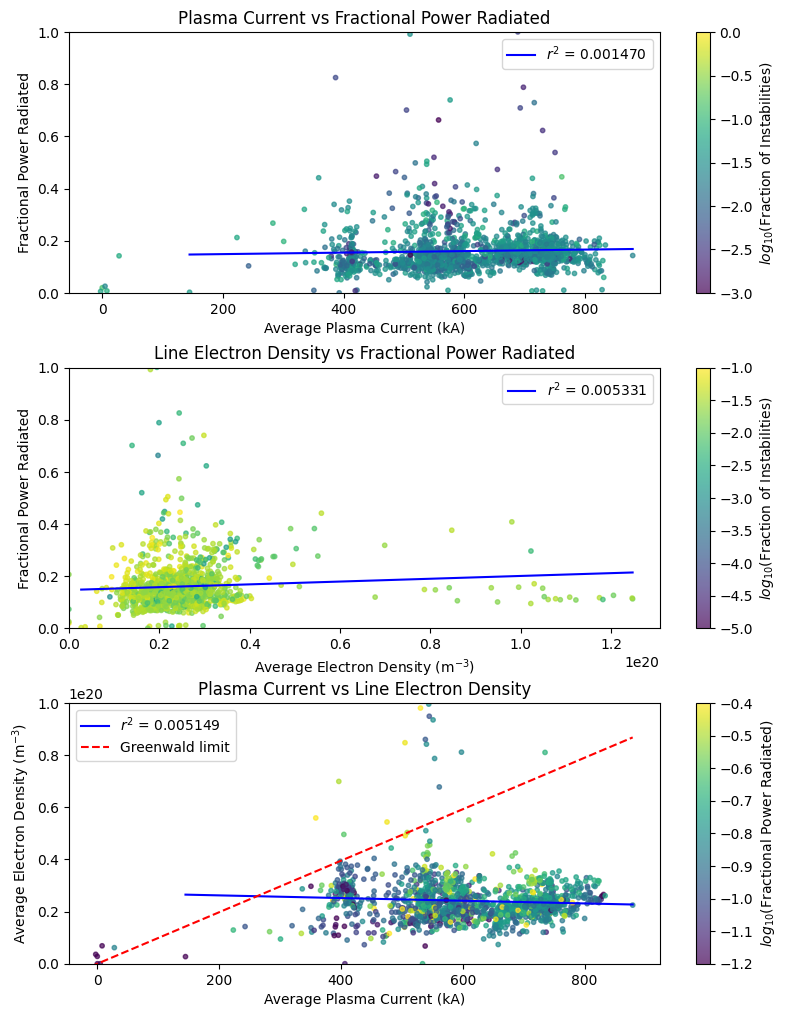

In [ ]:
# Pick between reading from file, or running the function to get the data from S3 and save to file
#df = many_shots_getting_data(25000, 30000)

df = pd.read_csv('mast_radiated_power_results.csv')

if df.empty:
    print("No valid shots found")
else:
    plotting_things(df)

As can be seen, there is little correlation between each plot. This may be due to the limitations in the method, or the data itself. The Greenwald density limit is covering the majority of the data except for a few outliers, which may have been during significant events.

In order to get the data from each shot, the mean was found, the data used for the mean was sliced such that the power NBI was close to steady state. The standard deviation in this mean was then used to classify points where radiation spikes happened. The issue with this is that it does not know whether something was a controlled change, or if it were an uncontrolled change, furthermore, the data itself can be easily skewered and manipulated by outliers from bad data readings or data that missed the slicing.

The thousands of shots collated would have different experimental objectives, and therefore, different conditions, meaning this data may not be fair to compare.

The Pearson analysis assumes linear fits, therefore, any non-linear behaviour will not be considered a correllation, furthermore, information about uncertainties was not used, therefore, all data points were weighed to be the same.